In [1]:
import os
from getpass import getpass
from urllib.parse import quote

REPO_URL = "https://github.com/williamsnunezp/prediccion-atenciones-medicas-salud.git"
REPO_DIR = "/content/prediccion-atenciones-medicas-salud"

token = os.getenv("GITHUB_TOKEN")
if token is None:
    token = getpass("GitHub token (deja vacío si el repo es público o ya fue cargado): ").strip()

if token:
    token = quote(token, safe="")
    clone_url = REPO_URL.replace("https://", f"https://{token}@")
else:
    clone_url = REPO_URL

cloned = False
if not os.path.exists(REPO_DIR):
    !git clone {clone_url} {REPO_DIR}
    cloned = True
else:
    print("Ya existe:", REPO_DIR)

print(os.listdir(REPO_DIR))

if cloned:
    print('Preparando entorno...')
    !pip install kaleido==0.2.1




Cloning into '/content/prediccion-atenciones-medicas-salud'...
remote: Enumerating objects: 392, done.
remote: Counting objects: 100% (122/122), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 392 (delta 45), reused 88 (delta 21), pack-reused 270 (from 1)
Receiving objects: 100% (392/392), 79.75 MiB | 21.14 MiB/s, done.
Resolving deltas: 100% (156/156), done.
['data', 'requirements.txt', '.git', '.gitignore', 'articles', 'README.md', 'notebooks', '.vscode']
Preparando entorno...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 9.0 MB/s eta 0:00:000:00:0100:01


# **Fase 1: Comprensión del negocio (CRISP-DM)**

## 1.1. Determinar objetivos del negocio

### Antecedentes

El Hospital María Auxiliadora es un hospital de apoyo ubicado en Lima, Perú, que ofrece consultas médicas en múltiples especialidades. El hospital cuenta con un sistema de gestión de citas médicas que registra información de pacientes, diagnósticos y asistencia. El dataset utilizado contiene **450,629 registros** correspondientes al año 2023.

### Objetivos del negocio

El objetivo principal es **optimizar la gestión hospitalaria** mediante un modelo predictivo que anticipe las inasistencias de los pacientes a sus consultas médicas. Esto permitirá:

- **Mejorar la asignación de recursos** (médicos, personal y equipamiento)
- **Reducir la congestión** en las instalaciones
- **Aumentar la calidad de la atención** al paciente
- **Optimizar el uso del tiempo** y reducir la saturación innecesaria de los servicios de salud

### Criterios de éxito del negocio

- **Reducción de inasistencias**: Disminuir la tasa de no-show en al menos un 15%
- **Cobertura de predicción**: El modelo debe cubrir más del 95% de las citas programadas
- **Impacto operativo**: Mejorar la programación de turnos y reducir tiempos de espera

---

## 1.2. Evaluar la situación

### La Situación Problemática Actual en los Hospitales

La ausencia de sistemas predictivos para anticipar inasistencias genera ineficiencias críticas:

- **Capacidad ociosa**: Los turnos no anticipados dejan médicos, personal y equipos inactivos, generando altos costos fijos sin brindar atención
- **Barreras de acceso**: Otros pacientes en lista de espera ven retrasada su atención, deteriorando su estado de salud
- **Ruptura de continuidad**: El paciente que falta pierde seguimiento, aumentando el riesgo de hospitalizaciones de emergencia con costos exponencialmente mayores
- **Estrategias reactivas ineficientes**: Recordatorios masivos ciegos y sobrebooking generalizado que colapsan salas de espera cuando todos asisten

### Beneficios de la Propuesta Predictiva

- **Turnos reasignados preventivamente**: Identificar pacientes en riesgo permite ofrecer esos espacios a quienes están en lista de espera
- **Contacto administrativo focalizado**: Concentrar llamadas y reprogramación solo en pacientes con riesgo medio/alto de inasistencia
- **Sobreprogramación inteligente**: Diseñar un sistema de sobrecitas dinámico para especialidades con alta tasa de inasistencia
- **Continuidad del cuidado**: Asegurar que los pacientes vulnerables asistan a tiempo, previniendo complicaciones que saturen urgencias

---

## 1.3. Determinar objetivos de minería de datos

El objetivo técnico de la minería de datos es desarrollar un modelo de clasificación binaria altamente robusto que prediga la probabilidad de que un paciente no asista a su cita médica programada. Dado el desbalance de las clases y el alto impacto operativo de los turnos perdidos en el hospital, el foco principal de la analítica es maximizar la detección de inasistencias reales (clase minoritaria), utilizando la métrica de Recall (sensibilidad) como el criterio clave para el éxito del modelo. Para lograr esto, se implementarán técnicas avanzadas de balanceo de datos (como SMOTE e Instance Hardness Threshold) en combinación con algoritmos de gradient boosting, buscando obtener predicciones estables y confiables con un Recall superior al 80% y una baja variabilidad ante distintas semillas de entrenamiento.

---

## 1.4. Producir plan del proyecto

### Plan del proyecto (CRISP-DM)

| Fase | Nombre | Descripción |
|------|--------|-------------|
| **1** | Comprensión del negocio | Definir objetivos, evaluar situación, establecer metas |
| **2** | Conocimiento de los datos | Recolección, descripción, exploración y verificación de calidad |
| **3** | Preparación de los datos | Limpieza, transformación, selección de features (10 variables) |
| **4** | Modelado | Optuna + XGBoost/LightGBM con 4 técnicas de balanceo |
| **5** | Evaluación | Análisis de Recall, Precision, AUC; comparación entre modelos |
| **6** | Despliegue | Ensamble IHT (promedio probabilidades), API REST, monitoreo |

# **Fase 2: Conociendo nuestros datos**
## 2.1. Recolección de los datos iniciales

El dataset utilizado en este proyecto fue obtenido de la plataforma de datos abiertos del gobierno del Perú. Contiene registros de citas médicas del Hospital de Apoyo María Auxiliadora durante el año 2023. Los datos fueron recopilados por el área de informática del hospital y están disponibles públicamente, lo que garantiza transparencia y legalidad en su uso. Este conjunto de datos incluye información relevante tanto del paciente como del servicio médico brindado, permitiendo un análisis predictivo confiable y enfocado en la asistencia a las citas médicas.

---

## 2.2. Descripción de los datos

El conjunto de datos contiene variables clave relacionadas con la atención médica, incluyendo características del paciente, detalles de la cita y ubicación del hospital. La variable objetivo del análisis es `ATENDIDO`, que indica si el paciente asistió (`VINO`) o no (`NO VINO`) a su cita.

A continuación, se resumen algunas variables principales:

| Variable            | Descripción                                             | Tipo de dato     |
|---------------------|---------------------------------------------------------|------------------|
| FECHA_CORTE         | Fecha del corte del dataset                             | Numérico         |
| ID                  | Identificador único del paciente (anonimizado)          | Alfanumérico     |
| DIA_CITA            | Fecha programada de la cita médica                      | Numérico         |
| ESPECIALIDAD        | Consultorio o especialidad de atención                  | Texto            |
| SEXO                | Sexo del paciente                                       | Texto            |
| EDAD                | Edad del paciente                                       | Numérico         |
| SEGURO              | Indica si el paciente cuenta con seguro de salud        | Texto            |
| PRESENCIAL_REMOTO   | Tipo de atención (presencial o remota)                  | Texto            |
| ATENDIDO            | Asistencia del paciente a su cita médica                | Texto            |
| MONTO               | Pago realizado por la cita médica (en soles)            | Numérico         |
| DEPARTAMENTO        | Departamento del hospital                               | Texto            |
| PROVINCIA       | Provincia del hospital                               | Texto            |
| DISTRITO       | Distrito del hospital                               | Texto            |
| UBIGEO              | Código geográfico de ubicación                          | Alfanumérico     |

---



In [2]:
# Librerías base
import pandas as pd
import pandas.api.types as ptypes
import os
import zipfile
import numpy as np
import nbformat
import warnings

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import kaleido
from IPython.display import HTML, display

# importancia de variables
from sklearn.feature_selection import f_classif, chi2, mutual_info_classif
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from scipy.stats import chi2_contingency
from sklearn.metrics import mutual_info_score
# Opcional
warnings.filterwarnings("ignore")


In [3]:
# Ruta al archivo ZIP
ruta_zip = os.path.join("/content/prediccion-atenciones-medicas-salud", "data", "dataraw.zip")

# Abrir el ZIP y listar archivos
with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    # Listar archivos en el ZIP
    archivos = zip_ref.namelist()
    print("Archivos en el ZIP:")
    print(archivos)
    
    # Leer el CSV directamente desde el ZIP con separador ";"
    archivo_csv = [f for f in archivos if f.endswith('.csv')][0]
    
    with zip_ref.open(archivo_csv) as csv_file:
        data = pd.read_csv(csv_file, sep=";")

display(data.tail(3))

Archivos en el ZIP:
['DATOS HOSPITAL MARIA AUXILIADORA.csv']


,FECHA_CORTE,ID,DIA_SOLICITACITA,DIA_CITA,ESPECIALIDAD,SEXO,EDAD,SEGURO,PRESENCIAL_REMOTO,ATENDIDO,MONTO,DEPARTAMENTO,PROVINCIA,DISTRITO,UBIGEO
450626,20240430,1373246,20231205,20231230,PSICOLOGIA,FEMENINO,8.0,SI,PRESENCIAL,NO,30,LIMA,LIMA,SAN JUAN DE MIRAFLORES,150133
450627,20240430,2118536,20231205,20231230,PSICOLOGIA,MASCULINO,6.0,SI,PRESENCIAL,NO,30,LIMA,LIMA,SAN JUAN DE MIRAFLORES,150133
450628,20240430,2346541,20231207,20231230,PSICOLOGIA,MASCULINO,11.0,NO,PRESENCIAL,NO,30,LIMA,LIMA,SAN JUAN DE MIRAFLORES,150133


## 2.3. Verificación de la calidad de los datos

*   **Información general de las variables:**
Se utiliza `data.info()` para obtener un resumen de las columnas, sus tipos de datos y la cantidad de valores no nulos. El dataset contiene 450,629 registros y 15 columnas (6 numéricas, 8 categóricas y 1 fecha). Esto permite identificar posibles inconsistencias en la estructura del dataset.

*   **Cantidad de atributos en variables categóricas:**
Con `data.describe()` y la inspección de los valores únicos en variables como SEXO, SEGURO, PRESENCIAL_REMOTO, MONTO y ATENDIDO, se revisa la diversidad de categorías y se detectan codificaciones erróneas o valores inesperados. Se identifican 63 especialidades, 2 sexos, 2 tipos de atención y 4 montos.

*   **Detección de datos faltantes:**
El comando `data.isnull().sum()` contabiliza los valores nulos por columna. Se detectan **3 valores nulos en SEGURO** y **1 valor nulo en EDAD**, lo que ayuda a definir estrategias de imputación o limpieza.

*   **Estadísticas de variables numéricas:**
Se seleccionan las variables EDAD y MONTO para generar estadísticas descriptivas (media, desviación estándar, percentiles, etc.). Se observa que EDAD tiene un valor mínimo de **-5** (outlier/valor inválido) y un máximo de 107, con una media de 46.5 años.

*   **Identificación de outliers:**
Se construyen boxplots para cada variable numérica, lo que proporciona una visualización clara de la dispersión y posibles valores atípicos. Se confirma que EDAD tiene valores negativos que deben ser tratados. Esta representación gráfica es clave para decidir si los outliers deben ser tratados o mantenidos según el contexto del análisis.

In [7]:
#2.3. Informacion de las variables
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450629 entries, 0 to 450628
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   FECHA_CORTE        450629 non-null  int64  
 1   ID                 450629 non-null  int64  
 2   DIA_SOLICITACITA   450629 non-null  int64  
 3   DIA_CITA           450629 non-null  int64  
 4   ESPECIALIDAD       450629 non-null  object 
 5   SEXO               450629 non-null  object 
 6   EDAD               450628 non-null  float64
 7   SEGURO             450626 non-null  object 
 8   PRESENCIAL_REMOTO  450629 non-null  object 
 9   ATENDIDO           450629 non-null  object 
 10  MONTO              450629 non-null  int64  
 11  DEPARTAMENTO       450629 non-null  object 
 12  PROVINCIA          450629 non-null  object 
 13  DISTRITO           450629 non-null  object 
 14  UBIGEO             450629 non-null  int64  
dtypes: float64(1), int64(6), object(8)
memory usage: 51

In [5]:
#2.3. Cantidad de atributos en las variables categotivas
data.describe()
print(f"Valores unicos de Especialidad: {data["ESPECIALIDAD"].nunique()}")
print(f"Valores unicos de Sexo: {data["SEXO"].unique()}")
print(f"Valores unicos de ID: {data["ID"].nunique()}")
print(f"Valores unicos de SEGURO: {data["SEGURO"].unique()}")
print(f"Valores unicos de PRESENCIAL_REMOTO:{data["PRESENCIAL_REMOTO"].unique()}")
print(f"Valores unicos de MONTO: {data['MONTO'].unique()}")
print(f"Valores unicos de ATENDIDO: {data["ATENDIDO"].unique()}")

Valores unicos de Especialidad: 63
Valores unicos de Sexo: ['FEMENINO' 'MASCULINO']
Valores unicos de ID: 97549
Valores unicos de SEGURO: ['SI' 'NO' nan]
Valores unicos de PRESENCIAL_REMOTO:['REMOTO' 'PRESENCIAL']
Valores unicos de MONTO: [33  7 30 26]
Valores unicos de ATENDIDO: ['SI' 'NO']


In [6]:
#2.3. Canidad de datos faltantes por columna
data.isnull().sum().sort_values(ascending=False)

,0
SEGURO,3
EDAD,1
ID,0
DIA_SOLICITACITA,0
DIA_CITA,0
ESPECIALIDAD,0
FECHA_CORTE,0
SEXO,0
PRESENCIAL_REMOTO,0
ATENDIDO,0


In [7]:
#2.3. Estadicticas de las variables numericas relevantes
v_numericas = data[['EDAD','MONTO']]
v_numericas.describe()

,EDAD,MONTO
count,450628.000000,450629.000000
mean,46.511156,12.544554
std,23.548926,10.127518
min,-5.000000,7.000000
25%,29.000000,7.000000
50%,50.000000,7.000000
75%,65.000000,7.000000
max,107.000000,33.000000


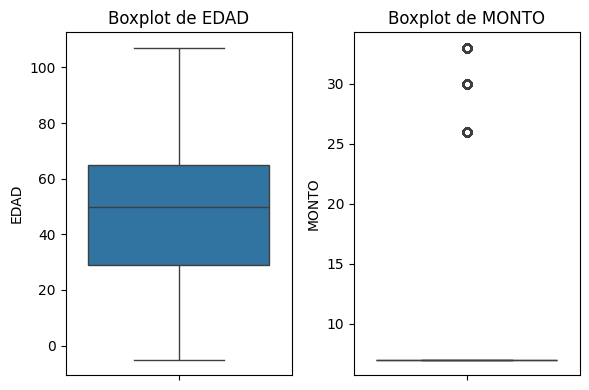

In [8]:
# 2.3. Identificar outliers, creando subplots para cada columna

plt.figure(figsize=(6, 4))
for i, columna in enumerate(v_numericas.columns):
    plt.subplot(1, len(v_numericas.columns), i+1)
    sns.boxplot(data=data, y=columna)
    plt.title(f"Boxplot de {columna}")
plt.tight_layout()
plt.show()

## 2.4. Exploración de los datos

*   **Especialidad y atención:**
Se grafican las frecuencias de cada especialidad y su relación con la variable ATENDIDO, lo que permite identificar cuáles son más comunes y cómo varía la tasa de inasistencia en cada una.

*   **Variables categóricas vs. atención:**
Se generan gráficos de barras apilados (stacked) para SEXO, SEGURO, PRESENCIAL_REMOTO y MONTO, mostrando la distribución porcentual de asistencia/inasistencia dentro de cada categoría. Esto revela, por ejemplo, que las consultas remotas tienen mayor tasa de inasistencia.

*   **Filtrado de especialidades:**
Se eliminan las especialidades donde más del 90% de los registros pertenecen a una sola clase (VINO o NO VINO), ya que no aportan información útil para la clasificación. Se crea `data3` con las especialidades relevantes.

*   **Comparación data2 vs data3:**
Se comparan visualmente las distribuciones de variables entre el dataset original (data2) y el dataset filtrado (data3) usando subplots, para verificar que el filtrado no distorsione los patrones principales.

*   **Distribución del target (ATENDIDO):**
Un gráfico de pastel muestra el porcentaje de pacientes atendidos y no atendidos, evidenciando el desbalance de clases (aprox. 68% asistieron, 32% inasistencias).

*   **Edad:**
Se analiza con diagramas de caja la distribución de la edad frente a variables categóricas, detectando diferencias y posibles outliers (valores negativos en EDAD).

In [9]:
data.columns

Index(['FECHA_CORTE', 'ID', 'DIA_SOLICITACITA', 'DIA_CITA', 'ESPECIALIDAD',
       'SEXO', 'EDAD', 'SEGURO', 'PRESENCIAL_REMOTO', 'ATENDIDO', 'MONTO',
       'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'UBIGEO'],
      dtype='object')

In [ ]:
#2.4. Grafico de barras (cuantitativo) de "Especialidad"
#display(data['ESPECIALIDAD'].value_counts(ascending=True).head(15))
order = data['ESPECIALIDAD'].value_counts().index
plt.figure(figsize=(20, 8))
sns.countplot(data=data, x="ESPECIALIDAD", order = order, palette= 'blend:#7AB,#EDA')
#annotate_bars_percentage(ax)
plt.title("CONTEO DE ESPECIALIDAD")
plt.xticks(rotation=90)
#plt.show()

In [4]:
data2 = data[['ESPECIALIDAD','SEXO', 'SEGURO', 'PRESENCIAL_REMOTO', 'MONTO', 'ATENDIDO','EDAD']].copy()
for col in data2.columns:
    if col =='EDAD':
        continue
    data2[col]= data2[col].astype('category')


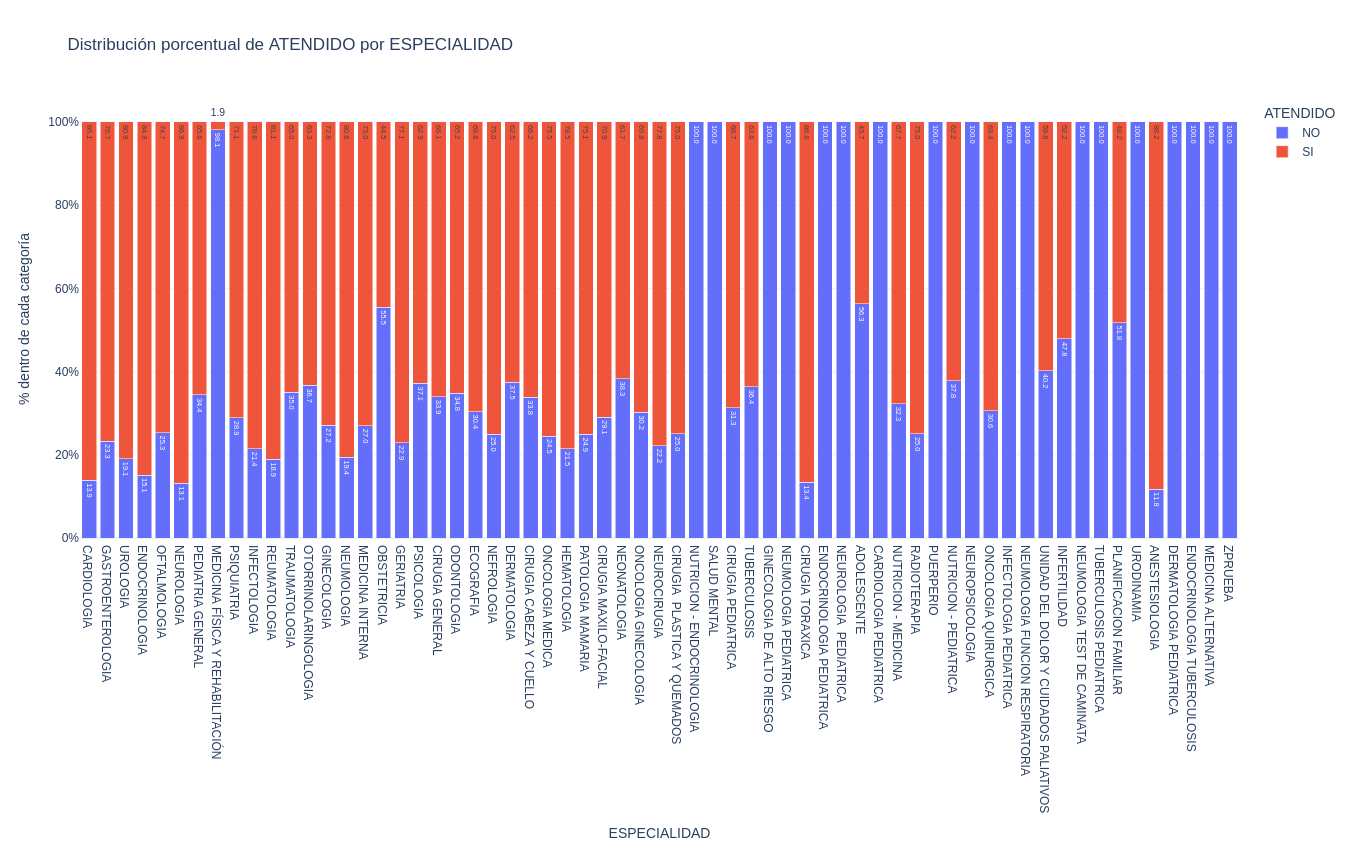

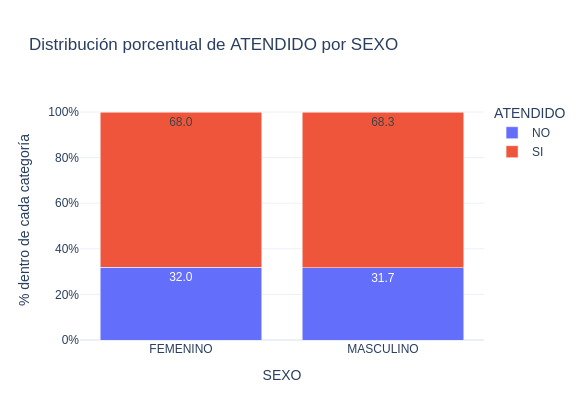

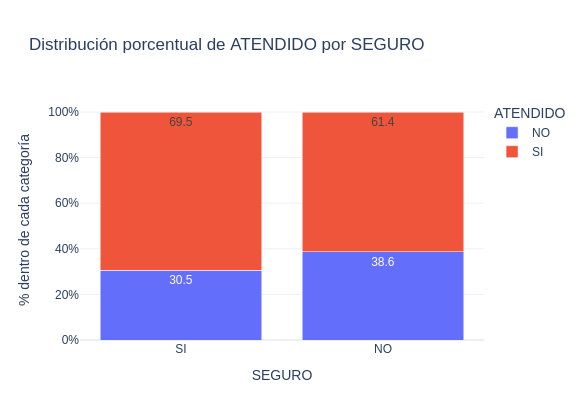

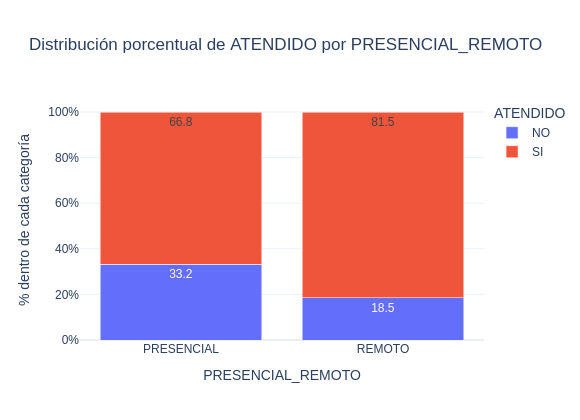

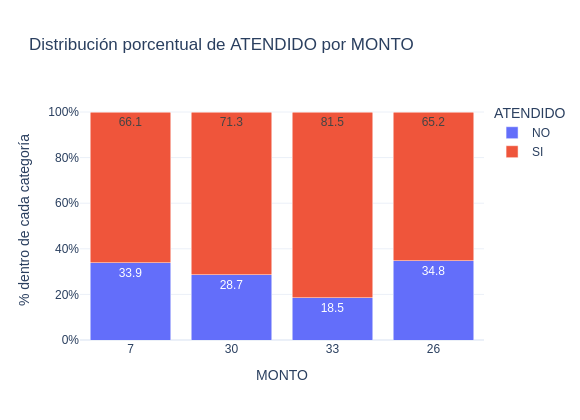

In [5]:
#os.makedirs("outputs", exist_ok=True)
for col in data2.columns:
    if col in ["ATENDIDO", 'EDAD']:
        continue
    orden = data2[col].value_counts().index.tolist()
    tabla = pd.crosstab(data2[col], data2["ATENDIDO"], normalize="index") * 100
    tabla = tabla.reset_index()

    tabla_larga = tabla.melt(
        id_vars=col,
        var_name="ATENDIDO",
        value_name="porcentaje"
    )

    fig = px.bar(
        tabla_larga,
        x=col,
        y="porcentaje",
        color="ATENDIDO",
        barmode="stack",
        text_auto=".1f",
        title=f"Distribución porcentual de ATENDIDO por {col}",
        labels={"porcentaje": "% dentro de cada categoría", col: col},
        category_orders={col: orden} 
    )
    fig.update_xaxes(type="category")
#    fig.update_layout(bargap=0.05)
    if col == "ESPECIALIDAD":
        fig.update_layout(template="plotly_white", height=850,width=1350)
    else:
        fig.update_layout(template="plotly_white", height=420,width=580)
    fig.update_yaxes(ticksuffix="%")
    pio.renderers.default = "png"
    #fig.write_image("outputs/grafico.png", engine='Kaleido')
    fig.show()


In [6]:
# calcular proporciones por categoría
probs = (
    data2.groupby('ESPECIALIDAD')['ATENDIDO']
        .value_counts(normalize=True)
        .unstack(fill_value=0)
)

# detectar categorías con >= 90% de negativos o >= 90% de positivos
drop_levels = probs[
    (probs.get('NO', 0) >= 0.9) | (probs.get('SI', 0) >= 0.9)
].index

# eliminar filas con esas categorías
data3 = data2[~data2['ESPECIALIDAD'].isin(drop_levels)].copy()

# si es categoría, limpiar niveles no usados
data3['ESPECIALIDAD'] = data3['ESPECIALIDAD'].cat.remove_unused_categories()


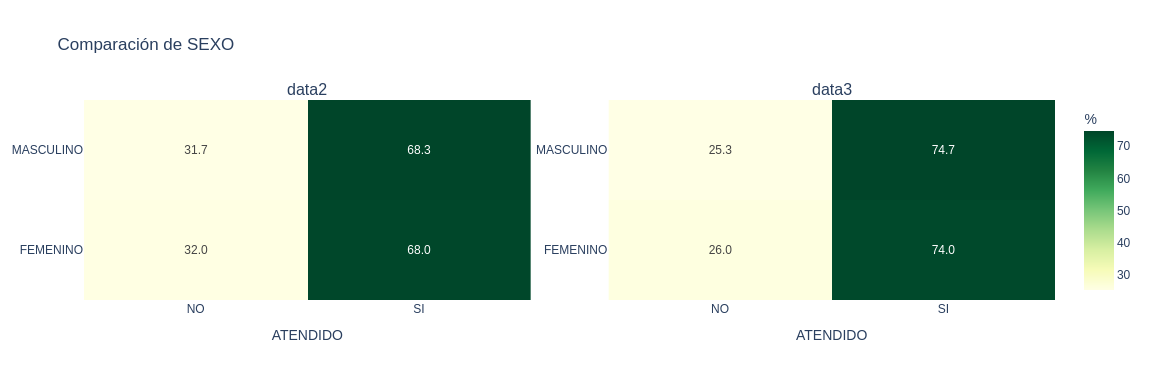

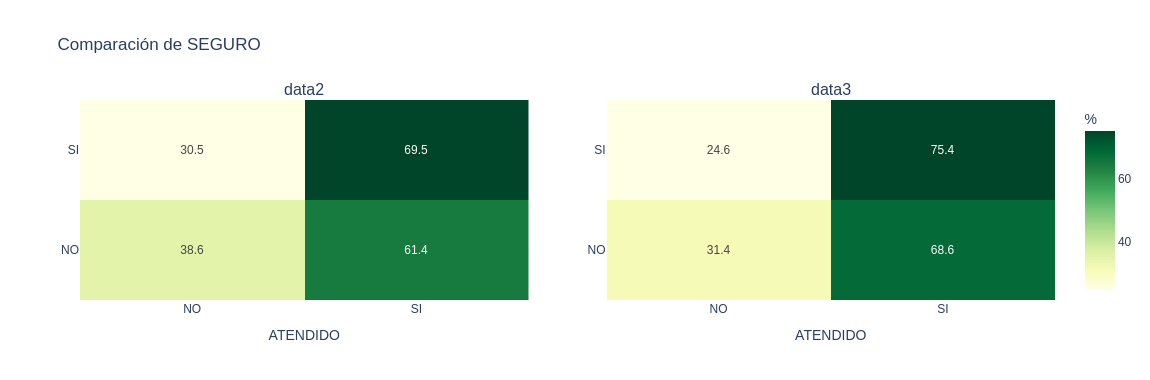

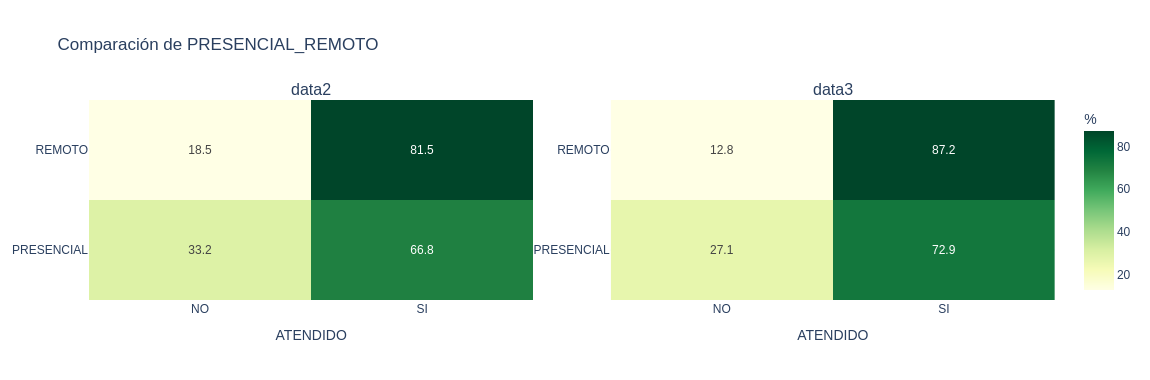

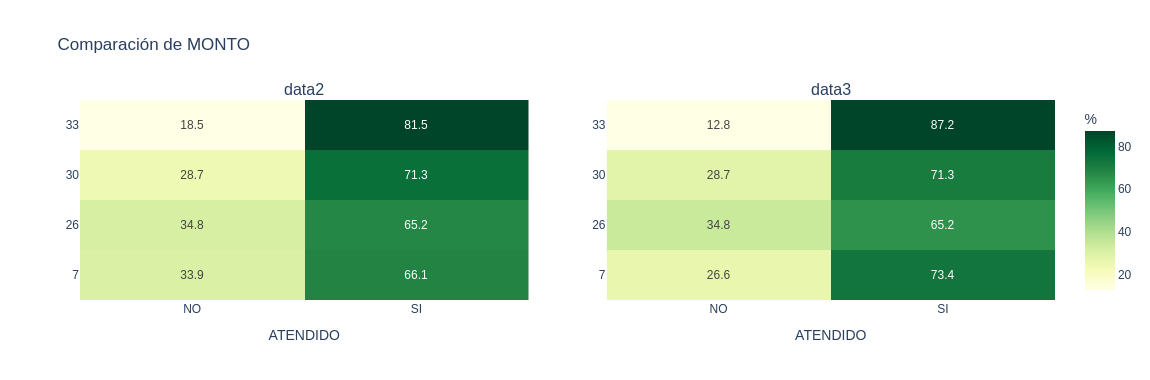

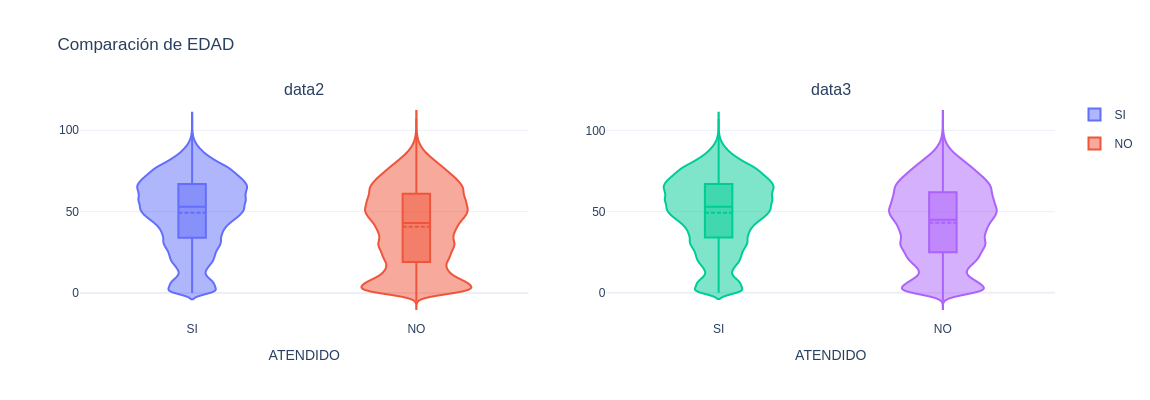

In [7]:
dfs = {'data2':data2, 'data3':data3}

for col in data2.columns:
    if col in ["ATENDIDO", "ESPECIALIDAD"]:
        continue

    is_numeric = ptypes.is_numeric_dtype(data2[col])

    fig = make_subplots(
        rows=1,
        cols=2,
        subplot_titles=list(dfs.keys()),
        horizontal_spacing=0.08
    )

    for i, (nombre_df, df) in enumerate(dfs.items(), start=1):
        if is_numeric:
            # mismo criterio que tu lógica original, pero listo para subplots
            for atendido in df["ATENDIDO"].dropna().unique():
                subset = df[df["ATENDIDO"] == atendido]

                fig.add_trace(
                    go.Violin(
                        x=[atendido] * len(subset),
                        y=subset[col],
                        name=str(atendido),
                        box_visible=True,
                        points="outliers",
                        meanline_visible=True,
                        legendgroup=str(atendido),
                        showlegend=(i == 1),
                    ),
                    row=1, col=i
                )

        else:
            tabla = pd.crosstab(df[col], df["ATENDIDO"], normalize="index") * 100

            fig.add_trace(
                go.Heatmap(
                    z=tabla.values,
                    x=tabla.columns.astype(str),
                    y=tabla.index.astype(str),
                    text=tabla.values,
                    texttemplate="%{text:.1f}",
                    colorscale="ylgn",
                    showscale=(i == 2),
                    colorbar=dict(title="%") if i == 2 else None,
                ),
                row=1, col=i
            )

    fig.update_layout(
        template="plotly_white",
        height=400 if is_numeric else 380,
        width=1150,
        title_text=f"Comparación de {col}"
    )

    fig.update_xaxes(title_text="ATENDIDO")
    fig.show()

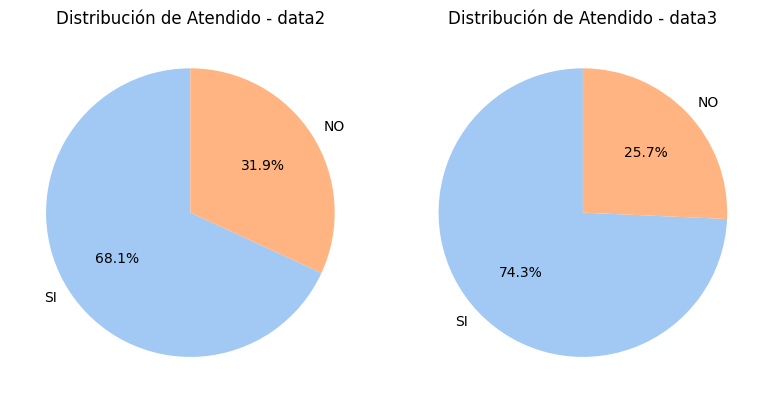

In [8]:
#2.4. Gráfico de pastel del target (Atendido)
fig, axes = plt.subplots(1, 2, figsize=(8,4))

for ax, (nombre_df, df) in zip(axes, dfs.items()):
    df["ATENDIDO"].value_counts().plot.pie(
        autopct="%1.1f%%",
        startangle=90,
        colors=sns.color_palette("pastel"),
        ax=ax
    )
    ax.set_title(f"Distribución de Atendido - {nombre_df}")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

In [38]:
data.columns

Index(['FECHA_CORTE', 'ID', 'DIA_SOLICITACITA', 'DIA_CITA', 'ESPECIALIDAD',
       'SEXO', 'EDAD', 'SEGURO', 'PRESENCIAL_REMOTO', 'ATENDIDO', 'MONTO',
       'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'UBIGEO'],
      dtype='object')

## 2.5. Importancia de variables

Se evalúa la importancia de cada variable respecto a la variable objetivo (ATENDIDO) utilizando tres métodos complementarios:

*   **Variables numéricas (EDAD):** Se aplican **F-test** (ANOVA) y **Mutual Information** para medir la relación lineal y no lineal con el target.

*   **Variables categóricas generales:** Se calcula **Cramér's V** (basado en Chi-cuadrado) y **Mutual Information** para ESPECIALIDAD, SEXO, SEGURO, PRESENCIAL_REMOTO y MONTO.

*   **Variables categóricas a nivel dummy:** Se aplica **Chi-cuadrado** y **Mutual Information** a cada categoría individual (one-hot encoding) para identificar qué categorías específicas tienen mayor poder discriminativo.

> **Resultado**: Las variables con mayor importancia son **ESPECIALIDAD** (Cramér's V = 0.214) y **EDAD** (eta² = 0.014).

In [ ]:
# Análisis combinado — sólo para data3
df = data3.copy()
target_col = 'ATENDIDO'

# Columnas numericas y categoricas
num_cols = df.drop(columns=[target_col]).select_dtypes(include='number').columns.tolist()
cat_cols = df.drop(columns=[target_col]).select_dtypes(include=['category']).columns.tolist()

# Limpieza: eliminar filas con NA en las columnas necesarias
df = df.dropna(subset=[target_col] + num_cols + cat_cols).copy()

# preparar X_num y target
y_num = df[target_col].cat.codes.values
X_num = df[num_cols].values

print('\n' + '='*60)
print('DATAFRAME: data3')
print('='*60)

print('\n=== NUMÉRICAS: F-test y Mutual Information ===')
f_scores, f_pvalues = f_classif(X_num, y_num)
mi_scores_num = mutual_info_classif(X_num, y_num, random_state=42)
n , k = len(y_num), len(np.unique(y_num))
eta_squared = (f_scores * (k - 1)) / (f_scores * (k - 1) + (n - k))

resultado_num = pd.DataFrame({
    'variable': num_cols,
    'f_score': f_scores,
    'f_pvalue': f_pvalues,
    'mutual_info': mi_scores_num,
    'eta_squared': eta_squared
})
print(resultado_num.sort_values('mutual_info', ascending=False).to_string(index=False))

print('\n=== CATEGORICAS GENERAL ===')
resultados = []
for col in cat_cols:
    ct = pd.crosstab(df[col], df[target_col]).values
    chi2_stat, p, _, _ = chi2_contingency(ct)
    n = ct.sum()
    v = np.sqrt(chi2_stat / (n * (min(ct.shape) - 1)))
    mi = mutual_info_score(df[col], df[target_col])
    resultados.append({'variable': col, 'cramers_v': v, 'chi2_pvalue': p, 'mutual_info': mi})

resultado_cat_gen = pd.DataFrame(resultados)
print(resultado_cat_gen.sort_values('cramers_v', ascending=False))


print('\n=== CATEGÓRICAS (DUMMY-LEVEL) ===')
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat_ohe = ohe.fit_transform(df[cat_cols])
cat_ohe_cols = ohe.get_feature_names_out(cat_cols)
chi2_scores, chi2_pvalues = chi2(X_cat_ohe, y_num)
mi_scores_cat = mutual_info_classif(X_cat_ohe, y_num, discrete_features=True, random_state=42)
n = X_cat_ohe.shape[0]

resultado_cat = pd.DataFrame({
    'cramers_v': np.sqrt(chi2_scores / n), 
    'mutual_info': mi_scores_cat,     
    'variable_dummy': cat_ohe_cols,
    'chi2_score': chi2_scores,
    'count': X_cat_ohe.sum(axis=0)
})
print(resultado_cat.sort_values('cramers_v', ascending=False).to_string(index=False))


DATAFRAME: data3

=== NUMÉRICAS: F-test y Mutual Information ===


variable     f_score  f_pvalue  mutual_info  eta_squared
    EDAD 5680.706393       0.0     0.007901     0.013577

=== CATEGORICAS GENERAL ===
            variable  cramers_v    chi2_pvalue  mutual_info
0       ESPECIALIDAD   0.213777   0.000000e+00     0.022433
4              MONTO   0.099970   0.000000e+00     0.005600
3  PRESENCIAL_REMOTO   0.095236   0.000000e+00     0.005171
2             SEGURO   0.057994  7.862389e-304     0.001625
1               SEXO   0.008029   2.491320e-07     0.000032

=== CATEGÓRICAS (DUMMY-LEVEL) ===
 cramers_v  mutual_info                                      variable_dummy  chi2_score    count
  0.113770 5.731757e-03                            ESPECIALIDAD_OBSTETRICIA 5342.399563  11526.0
  0.090630 5.170767e-03                                            MONTO_33 3390.177602  39031.0
  0.090630 5.170767e-03                            PRESENCIAL_REMOTO_REMOTO 3390.177602  39031.0
  0.081491 4.106776e-03                            ESPECIALIDAD_CARDIOLOGI

In [15]:
# 2.5. Análisis de pacientes sin/con múltiples citas

# VALIDACIÓN DE DATOS 
data3['ID'] = data['ID']
total_registros = len(data3)
citas_por_paciente = data3.groupby('ID').size() # Agrupamos por ID para contar cuántas citas tiene cada paciente

pacientes_unica_cita = citas_por_paciente[citas_por_paciente == 1].count()# Segmentamos pacientes
pacientes_multi_cita = citas_por_paciente[citas_por_paciente > 1].count()
total_pacientes_unicos = len(citas_por_paciente)

suma_registros_validada = citas_por_paciente.sum() # Calculamos la suma de registros desde la agrupación

print("--- REPORTE DE VALIDACIÓN ---")
print(f"Total Registros en DataFrame: {total_registros}")
print(f"Suma de citas por paciente:   {suma_registros_validada}")
print(f"¿Concuerdan los datos?        {'SÍ' if total_registros == suma_registros_validada else 'NO'}")
print("-" * 30)
print(f"Total Pacientes Únicos:       {total_pacientes_unicos}")
print(f" > Pacientes con 1 sola cita: {pacientes_unica_cita} ({(pacientes_unica_cita/total_pacientes_unicos)*100:.1f}%)")
print(f" > Pacientes recurrentes:     {pacientes_multi_cita} ({(pacientes_multi_cita/total_pacientes_unicos)*100:.1f}%)")

--- REPORTE DE VALIDACIÓN ---
Total Registros en DataFrame: 412747
Suma de citas por paciente:   412747
¿Concuerdan los datos?        SÍ
------------------------------
Total Pacientes Únicos:       93657
 > Pacientes con 1 sola cita: 32834 (35.1%)
 > Pacientes recurrentes:     60823 (64.9%)
